# **Import required libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# **Load and preprocess data**
This portion is to further prepare the data for initial exploratory data analysis. 
- Create a proper `'Date'` column for time-series analysis
- Calculate Monthly and Yearly average prices

From the visualization graphs, we can see an overall increasing trend in resale flat prices from $442246 in 2017 to $617867 in 2025. Particularly, we notice that the prices have:
- A plateau in 2019 to 2020
- A short period of decrease before increasing rapidly after mid-2020
    - The Straits Times reported that the **prices rose 5% in 2020** and the **transaction volume increased by 4.4%** from 2019. The writers explained that this increase, despite the economy being hit by the Covid-19 pandemic, is not surprising given the **extensive government stimulus** such as the Jobs Support Scheme to support the economy, giving buyers the condifence that they will be able to service their loan. (Source: [The Straits Times](https://www.straitstimes.com/business/property/sales-of-hdb-resale-flats-hit-8-year-high-in-2020-as-prices-climb-5))

## Resale Flat Data

In [4]:
df = pd.read_csv('../datasets/Final_ResaleData.csv')
print('Dataset shape:', df.shape)
df.sample(5)

Dataset shape: (212868, 10)


,Year,Month,Storey,Floor_Area,Remaining_Lease,Price,Distance_MRT,Distance_Mall,Within_1km_of_Pri,Mature
21904,2018,2,4,103.0,69.250,345000.0,1238,720,True,False
122679,2022,8,4,110.0,79.500,495000.0,831,968,True,False
9593,2017,6,10,125.0,81.167,445588.0,570,1162,False,False
190594,2024,7,7,68.0,92.917,470000.0,786,1732,False,False
78023,2020,9,10,92.0,94.333,938000.0,352,396,True,True


In [5]:
df.describe()
df.dtypes

Year                   int64
Month                  int64
Storey                 int64
Floor_Area           float64
Remaining_Lease      float64
Price                float64
Distance_MRT           int64
Distance_Mall          int64
Within_1km_of_Pri       bool
Mature                  bool
dtype: object

In [17]:
# Add 'Date' column
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Year,Month,Storey,Floor_Area,Remaining_Lease,Price,Distance_MRT,Distance_Mall,Within_1km_of_Pri,Mature,Date,Within_1km_of_Pri_Int,Mature_Int
0,2017,1,10,44.0,61.333,232000.0,1148,1276,True,True,2017-01-01,1,1
1,2017,1,1,100.0,81.750,342000.0,780,759,True,False,2017-01-01,1,0
2,2017,1,4,100.0,81.333,335000.0,558,385,True,False,2017-01-01,1,0
3,2017,1,1,86.0,82.500,305000.0,851,830,True,False,2017-01-01,1,0
4,2017,1,19,110.0,88.917,860000.0,293,737,False,True,2017-01-01,0,1


In [13]:
# Calculate Monthly Average Prices
monthly_avg_prices = df.groupby('Date').agg({
    'Price': ['mean', 'median', 'std', 'count']
    }).reset_index()

monthly_avg_prices.columns = ['Date', 'Mean_Price', 'Median_Price', 'Std_Dev_Price', 'Transaction_Count']
monthly_avg_prices.sample(5)

# Calculate Yearly Average Prices
yearly_avg_prices = df.groupby('Year').agg({
    'Price': ['mean', 'median', 'std', 'count']
    }).reset_index()

yearly_avg_prices.columns = ['Year', 'Mean_Price', 'Median_Price', 'Std_Dev_Price', 'Transaction_Count']
yearly_avg_prices.sample(5)

print('Monthly Average Prices (first 5 rows):' )
print(monthly_avg_prices.head(5))
print('\nYearly Average Prices:')
print(yearly_avg_prices)


Monthly Average Prices (first 5 rows):
        Date     Mean_Price  Median_Price  Std_Dev_Price  Transaction_Count
0 2017-01-01  426443.598478      403000.0  130267.530484               1183
1 2017-02-01  446722.903137      415000.0  146588.271232               1084
2 2017-03-01  443729.275345      415000.0  144431.360286               1899
3 2017-04-01  437682.043377      408000.0  139008.292703               1836
4 2017-05-01  442003.979737      410000.0  145710.924400               1974

Yearly Average Prices:
   Year     Mean_Price  Median_Price  Std_Dev_Price  Transaction_Count
0  2017  442246.549403      410000.0  146053.062002              20452
1  2018  438775.588278      408000.0  152961.360201              21472
2  2019  430058.837131      400000.0  149934.544788              22112
3  2020  449820.332213      425000.0  149765.177374              23240
4  2021  505604.462313      480000.0  152752.358872              28794
5  2022  540876.684146      520000.0  156143.259282    

### Visualization of overall price trend

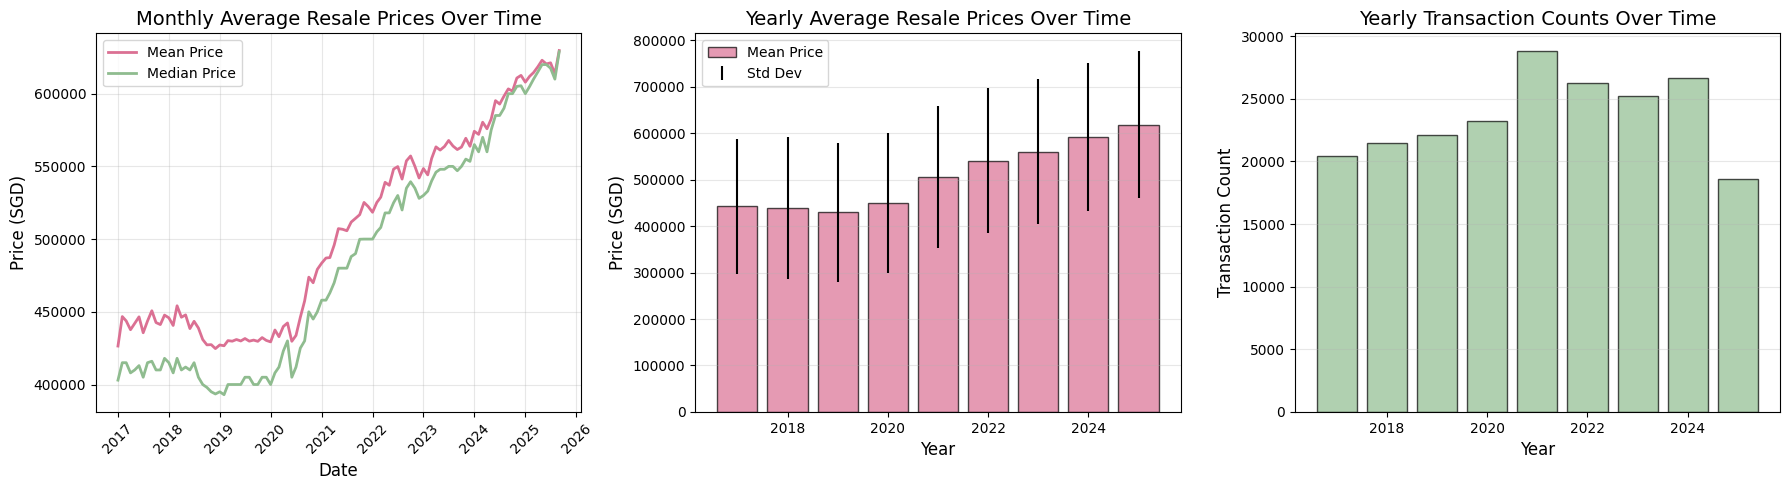

In [14]:
fig, ax =  plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Monthly Average Resale Prices Over Time
ax[0].plot(monthly_avg_prices['Date'], monthly_avg_prices['Mean_Price'],
           linewidth=2, label='Mean Price', color='palevioletred')
ax[0].plot(monthly_avg_prices['Date'], monthly_avg_prices['Median_Price'],
           linewidth=2, label='Median Price', color='darkseagreen')
ax[0].set_title('Monthly Average Resale Prices Over Time', fontsize=14)
ax[0].set_xlabel('Date', fontsize=12)
ax[0].set_ylabel('Price (SGD)', fontsize=12)
ax[0].legend(loc = 'upper left')
ax[0].grid(True, alpha=0.3)
ax[0].tick_params(axis='x', rotation=45)

# Plot 2: Yearly Average Resale Prices Over Time
ax[1].bar(yearly_avg_prices['Year'], yearly_avg_prices['Mean_Price'],
          color='palevioletred', alpha=0.7, label='Mean Price', edgecolor='black')
ax[1].errorbar(yearly_avg_prices['Year'], yearly_avg_prices['Mean_Price'],
               yerr=yearly_avg_prices['Std_Dev_Price'], fmt='none', color='black', label='Std Dev')
ax[1].set_title('Yearly Average Resale Prices Over Time', fontsize=14)
ax[1].set_xlabel('Year', fontsize=12)
ax[1].set_ylabel('Price (SGD)', fontsize=12)
ax[1].legend(loc = 'upper left')
ax[1].grid(True, alpha=0.3, axis = 'y')

# Plot 3: Yearly Transaction Counts Over Time
ax[2].bar(yearly_avg_prices['Year'], yearly_avg_prices['Transaction_Count'],
          color='darkseagreen', alpha=0.7, label='Transaction Count', edgecolor='black')
ax[2].set_title('Yearly Transaction Counts Over Time', fontsize=14)
ax[2].set_xlabel('Year', fontsize=12)
ax[2].set_ylabel('Transaction Count', fontsize=12)
ax[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### **Analyze Feature Correlations**

From the correlation table, we can see that:
- `'Floor_Area'` is highly correlated to `'Flat_Type'`
    - For this analysis, we choose to remove `'Flat_Type'` since `'Floor_Area'` is a better representation of the amount of space in the flat. Additionally, HDB will be rolling out (['white flats'](https://www.channelnewsasia.com/singapore/hdb-new-open-concept-layout-no-walls-beams-bto-kallang-whampoa-4365806)) from October 2025. By using floor area, it would better represent the future resale of these 'white flats' that might not have the same concept of 'number of rooms' as older flats. 
- `'Price'` is highly correlated to `'Floor_Area'`, `'Year'`, `'Remaining_Lease'` and `'Storey'`
- `'Price'` is less correlated to its distance to amenities such as malls and MRT stations

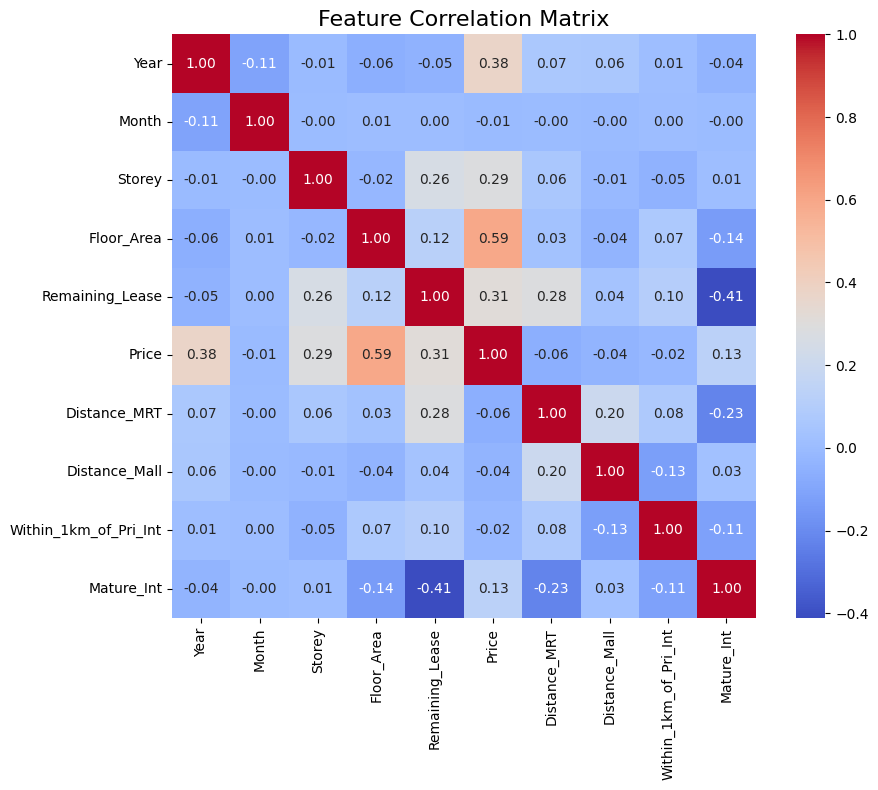

In [15]:
# Create correlation matrix for numerical features
numerical_features = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_features.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

### **Prepare data for modelling**

In [20]:
# Convert boolean features to integers
df['Within_1km_of_Pri_Int'] = df['Within_1km_of_Pri'].astype(int)
df['Mature_Int'] = df['Mature'].astype(int)

# The following features will be selected for modelling:
features = [ 
    'Year', 
    'Month',
    'Storey',
    'Floor_Area',
    'Remaining_Lease',
    'Distance_MRT',
    'Distance_Mall',
    'Within_1km_of_Pri_Int',
    'Mature_Int',
    ]

target = 'Price'

df1 = df[features + [target] + ['Date']].copy()
df1.dropna().reset_index(drop=True)

X = df1[features]
y = df1[target]

print(f"Total samples: {len(X)}")
print(f"Date range: {df1['Date'].min()} to {df1['Date'].max()}")

# Split data into training and testing sets chronologically (80% train, 20% test)
train_size = int(0.8 * len(X))
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Check training and testing dates
train_dates = df1['Date'].iloc[:train_size]
test_dates = df1['Date'].iloc[train_size:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}") 
print(f"Training period: {train_dates.min()} to {train_dates.max()}")
print(f"Testing period: {test_dates.min()} to {test_dates.max()}")


Total samples: 212868
Date range: 2017-01-01 00:00:00 to 2025-09-01 00:00:00
Training samples: 170294
Testing samples: 42574
Training period: 2017-01-01 00:00:00 to 2024-02-01 00:00:00
Testing period: 2024-02-01 00:00:00 to 2025-09-01 00:00:00


# **Random Forest**

Evaluation is carried out using MAE, RMSE and R^2 to assess prediction accuracy. The scores are as such:

MAE: 53219.98\
RMSE: 68633.35\
R2: 0.814

On average predictions are off by $53k on new data, and predictions are off by $68k when using RMSE. The model explains about 81.4% of the variation in prices. 

Most important feature is Floor Area


In [21]:
# Training Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100,
                                 random_state=42,
                                 max_depth=30,
                                 min_samples_split=5,
                                 min_samples_leaf=2,
                                 n_jobs=-1
                                 )

rf_model.fit(X_train, y_train)
print("Random Forest model training complete.")

Random Forest model training complete.


In [22]:
# Predicting on training set
y_train_pred_rf = rf_model.predict(X_train)
# Predicting on test set
y_test_pred_rf = rf_model.predict(X_test)

# Evaluation
# Mean Absolute Error (MAE)
rf_train_mae = mean_absolute_error(y_train, y_train_pred_rf)
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)

print(f"Random Forest Training MAE: {rf_train_mae}")
print(f"Random Forest Testing MAE: {rf_test_mae}")

# Root Mean Squared Error (RMSE)
rf_train_rmse = root_mean_squared_error(y_train, y_train_pred_rf)
rf_test_rmse = root_mean_squared_error(y_test, y_test_pred_rf)

print(f"Random Forest Training RMSE: {rf_train_rmse}")
print(f"Random Forest Testing RMSE: {rf_test_rmse}")

# R-squared (R2) Score
rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)

print(f"Random Forest Training R2: {rf_train_r2}")
print(f"Random Forest Testing R2: {rf_test_r2}")

Random Forest Training MAE: 12315.364499437503
Random Forest Testing MAE: 53219.98196980246
Random Forest Training RMSE: 18334.978512292306
Random Forest Testing RMSE: 68633.34883186591
Random Forest Training R2: 0.9869548837565388
Random Forest Testing R2: 0.8147863594457267


In [23]:
#Analyse Prediction Errors
rf_test_errors = y_test - y_test_pred_rf

within_50k = np.sum(np.abs(rf_test_errors) <= 50000)/len(y_test)*100
print(f"Percentage of test predictions within ±$50,000: {within_50k:.2f}%")
within_100k = np.sum(np.abs(rf_test_errors) <= 100000)/len(y_test)*100
print(f"Percentage of test predictions within ±$100,000: {within_100k:.2f}%")
more_than_100k = np.sum(np.abs(rf_test_errors) > 100000)/len(y_test)*100
print(f"Percentage of test predictions with error more than ±$100,000: {more_than_100k:.2f}%")

Percentage of test predictions within ±$50,000: 56.29%
Percentage of test predictions within ±$100,000: 87.49%
Percentage of test predictions with error more than ±$100,000: 12.51%


In [24]:
# Feature Importance for Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance (Random Forest):")
print(feature_importance)

Feature Importance (Random Forest):
                 Feature  Importance
3             Floor_Area    0.485229
4        Remaining_Lease    0.133716
8             Mature_Int    0.128131
0                   Year    0.118163
5           Distance_MRT    0.046071
6          Distance_Mall    0.040349
2                 Storey    0.032538
7  Within_1km_of_Pri_Int    0.008137
1                  Month    0.007667


# **Linear Regression**

Evaluation is carried out using MAE, RMSE and R^2 to assess prediction accuracy. The scores are as such:

MAE: 60805.22\
RMSE: 80252.47\
R2: 0.747

On average predictions are off by $60k on new data, and predictions are off by $80k when using RMSE. The model explains about 74.7% of the variation in prices. 

Most important feature is whether or not the estate is a mature one


In [25]:
# Training Linear Regression Model
lm = LinearRegression()
lm.fit(X_train, y_train)
print("Linear Regression model training complete.")

Linear Regression model training complete.


In [26]:
# Make predictions
y_train_pred_lm = lm.predict(X_train)
y_test_pred_lm = lm.predict(X_test)

# Evaluation
# Mean Absolute Error (MAE)
lm_train_mae = mean_absolute_error(y_train, y_train_pred_lm)
lm_test_mae = mean_absolute_error(y_test, y_test_pred_lm)
print(f"Linear Regression Training MAE: {lm_train_mae}")
print(f"Linear Regression Testing MAE: {lm_test_mae}")

# Root Mean Squared Error (RMSE)
lm_train_rmse = root_mean_squared_error(y_train, y_train_pred_lm)
lm_test_rmse = root_mean_squared_error(y_test, y_test_pred_lm)
print(f"Linear Regression Training RMSE: {lm_train_rmse}")
print(f"Linear Regression Testing RMSE: {lm_test_rmse}")

# R-squared (R2) Score
lm_train_r2 = r2_score(y_train, y_train_pred_lm)
lm_test_r2 = r2_score(y_test, y_test_pred_lm)
print(f"Linear Regression Training R2: {lm_train_r2}")
print(f"Linear Regression Testing R2: {lm_test_r2}")



Linear Regression Training MAE: 58588.57795613338
Linear Regression Testing MAE: 60805.22251578634
Linear Regression Training RMSE: 75936.34506468746
Linear Regression Testing RMSE: 80252.47880312317
Linear Regression Training R2: 0.7762379033010949
Linear Regression Testing R2: 0.7467674667595117


In [27]:
# Feature Importance for Linear Regression
lm_coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lm.coef_
})
lm_coefficients = lm_coefficients.sort_values(by='Coefficient', ascending=False)
print("Feature Coefficients (Linear Regression):")
print(lm_coefficients)

Feature Coefficients (Linear Regression):
                 Feature    Coefficient
8             Mature_Int  125879.119784
0                   Year   27333.280625
2                 Storey    6170.315406
4        Remaining_Lease    4625.202878
3             Floor_Area    4296.671717
1                  Month    1827.692534
6          Distance_Mall     -10.513011
5           Distance_MRT     -43.701712
7  Within_1km_of_Pri_Int  -26368.611623
